In [ ]:
# ========= CONFIG (fill locally; do NOT commit secrets) =========
# Tip: use environment variables or a local `.env` file.
# Example:
#   import os
#   OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "")
#   HF_TOKEN = os.getenv("HF_TOKEN", "")
# ===============================================================



#+++++++++++++++ Change the nearest neighbor measure

from a shift-driving patent to n-nearest neighbors in the company's portfolio instead of the other way around


# Initiation and preparation for dataset

In [1]:
import pandas as pd
from google.colab import drive
import os

# Parameters for dataset
sector = 'camera'
dataset = 'complete'

# The start year and end year of the overall dataset
start_year = 1930
end_year = 2023    # the year to end

# Choose the size of minimum cluster
min_cluster_size = 1000    # The larger the cluster size, the fewer the topics
year_window = 20

# Navigate the folder location
drive.mount("/content/drive")
folder_path = f"/content/drive/MyDrive/TechShiftProject/{sector}/{dataset}_data/"

# Prepare folders for further analysis
if dataset not in ("sampled", "test"):
    embedding_path = f'{folder_path}embedding_analysis_end_{end_year}/'
    dynamic_embedding_path = f'{folder_path}dynamic_embedding_{year_window}_end_{end_year}/'
    dynamic_topic_path = f'{folder_path}dynamic_topic_{min_cluster_size}_{year_window}_end_{end_year}/'
    comprehensive_path = f'{folder_path}comprehensive_{min_cluster_size}_end_{end_year}/'
else:
    embedding_path = f'{folder_path}embedding_analysis_{constant_patent_num}_{i_sampling}_end_{end_year}/'
    dynamic_embedding_path = f'{folder_path}dynamic_embedding_{year_window}_{constant_patent_num}_{i_sampling}_end_{end_year}/'
    dynamic_topic_path = f'{folder_path}dynamic_topic_{min_cluster_size}_{year_window}_{constant_patent_num}_{i_sampling}_end_{end_year}/'
    comprehensive_path = f'{folder_path}comprehensive_{min_cluster_size}_{constant_patent_num}_{i_sampling}_end_{end_year}/'

if not os.path.exists(dynamic_topic_path):
    os.makedirs(embedding_path)
    os.makedirs(dynamic_embedding_path)
    os.makedirs(dynamic_topic_path)
    os.makedirs(comprehensive_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Get companies technology portfolio with moving year windows


In [ ]:
# Parameters
moving_year_window = 5    # the years that compose the portfolio
# moving_year_window = 3
if_before_after = 'onpoint'
# if_before_after = 'after'

# Prepare the dataframe for all patents
df_id_year_document = pd.read_csv(f"{folder_path}df_id_year_document.csv")
df_id_year_document = df_id_year_document[(df_id_year_document["year"] >= start_year) & (df_id_year_document["year"] <= end_year)]
df_id_year_document.reset_index(drop=True, inplace=True)
df_id_year_document = df_id_year_document.drop(columns=['document'])    # Remove the document as it is not needed
print("Dataframe of all loaded")

# Prepare the dataframe related to companies
df_id_year_company = pd.read_csv(f"{folder_path}df_company_id_year.csv")
df_id_year_company = df_id_year_company[df_id_year_company['id'].isin(df_id_year_document['id'])]
df_id_year_company = df_id_year_company[(df_id_year_company["year"] >= start_year) & (df_id_year_company["year"] <= end_year)]
df_id_year_company.reset_index(drop=True, inplace=True)
print("Dataframe of company loaded")

# Create an empty DataFrame to store the dataframe of the moving window portfolio
df_company_year_portfolio = pd.DataFrame(columns=['company', 'year', 'id'])


# If before and after
if if_before_after == 'onpoint':
    for company in df_id_year_company['company'].unique():
        for year in range(start_year+moving_year_window-1, end_year+1):
            # Filter rows for this company within the last moving-window years including the focal year
            recent_ids = df_id_year_company[(df_id_year_company['company'] == company) &
                                            (df_id_year_company['year'] >= year - moving_year_window + 1) &
                                            (df_id_year_company['year'] <= year)]['id'].tolist()

            # Append to the new DataFrame if it is not empty
            if len(recent_ids) != 0:
                # Create a new DataFrame where each row represents a single id
                new_rows = pd.DataFrame({'company': company, 'year': year, 'id': recent_ids})

                # Append to the new DataFrame
                df_company_year_portfolio = pd.concat([df_company_year_portfolio, new_rows], ignore_index=True)
            print(company, year)


elif if_before_after == 'before':
    # Iterate over each year and each company starting from `start_year`
    for company in df_id_year_company['company'].unique():
        for year in range(start_year+moving_year_window, end_year+1):
            # Filter rows for this company within the last moving-window years including the focal year
            recent_ids = df_id_year_company[(df_id_year_company['company'] == company) &
                                            (df_id_year_company['year'] >= year - moving_year_window) &
                                            (df_id_year_company['year'] <= year - 1)]['id'].tolist()

            # Append to the new DataFrame if it is not empty
            if len(recent_ids) != 0:
                # Create a new DataFrame where each row represents a single id
                new_rows = pd.DataFrame({'company': company, 'year': year, 'id': recent_ids})

                # Append to the new DataFrame
                df_company_year_portfolio = pd.concat([df_company_year_portfolio, new_rows], ignore_index=True)
            print(company, year)

else:
    # Iterate over each year and each company starting from `start_year`
    for company in df_id_year_company['company'].unique():
        for year in range(start_year, end_year-moving_year_window+1):
            # Filter rows for this company within the last moving-window years including the focal year
            recent_ids = df_id_year_company[(df_id_year_company['company'] == company) &
                                            (df_id_year_company['year'] >= year + 1) &
                                            (df_id_year_company['year'] <= year + moving_year_window)]['id'].tolist()

            # Append to the new DataFrame if it is not empty
            if len(recent_ids) != 0:
                # Create a new DataFrame where each row represents a single id
                new_rows = pd.DataFrame({'company': company, 'year': year, 'id': recent_ids})

                # Append to the new DataFrame
                df_company_year_portfolio = pd.concat([df_company_year_portfolio, new_rows], ignore_index=True)
            print(company, year)

df_company_year_portfolio.to_csv(f'{embedding_path}df_company_year_portfolio_{if_before_after}.csv', index=False)
print("Dataframe saved to CSV file")

Streaming output truncated to the last 5000 lines.
d-link 1936
d-link 1937
d-link 1938
d-link 1939
d-link 1940
d-link 1941
d-link 1942
d-link 1943
d-link 1944
d-link 1945
d-link 1946
d-link 1947
d-link 1948
d-link 1949
d-link 1950
d-link 1951
d-link 1952
d-link 1953
d-link 1954
d-link 1955
d-link 1956
d-link 1957
d-link 1958
d-link 1959
d-link 1960
d-link 1961
d-link 1962
d-link 1963
d-link 1964
d-link 1965
d-link 1966
d-link 1967
d-link 1968
d-link 1969
d-link 1970
d-link 1971
d-link 1972
d-link 1973
d-link 1974
d-link 1975
d-link 1976
d-link 1977
d-link 1978
d-link 1979
d-link 1980
d-link 1981
d-link 1982
d-link 1983
d-link 1984
d-link 1985
d-link 1986
d-link 1987
d-link 1988
d-link 1989
d-link 1990
d-link 1991
d-link 1992
d-link 1993
d-link 1994
d-link 1995
d-link 1996
d-link 1997
d-link 1998
d-link 1999
d-link 2000
d-link 2001
d-link 2002
d-link 2003
d-link 2004
d-link 2005
d-link 2006
d-link 2007
d-link 2008
d-link 2009
d-link 2010
d-link 2011
d-link 2012
d-link 2013
d-link 2014
d

## Count patent numbers by year

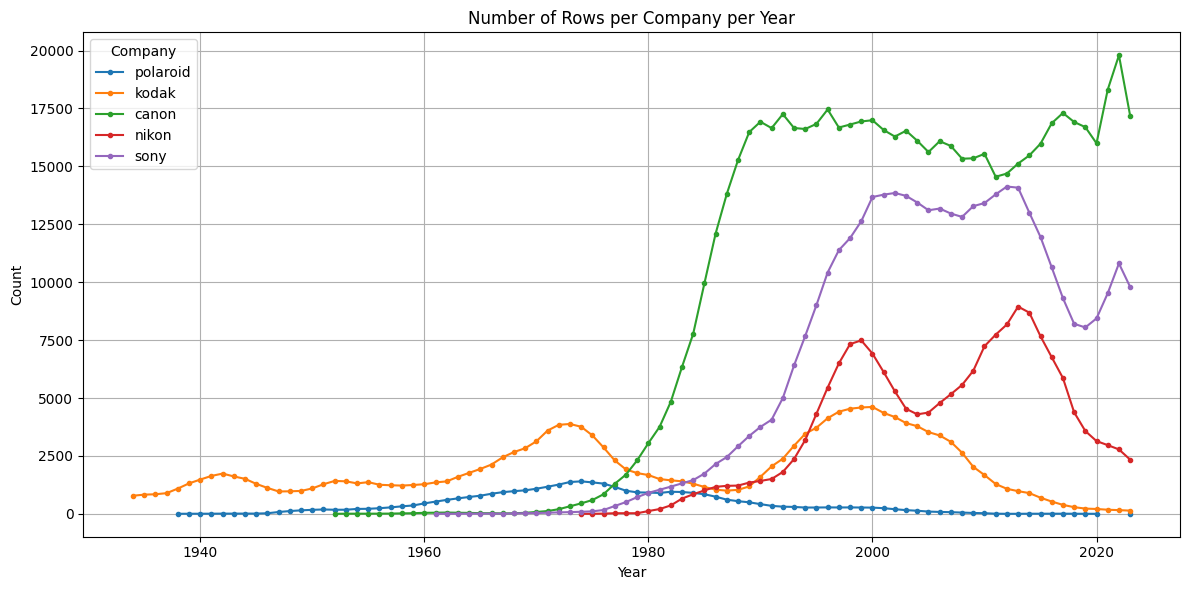

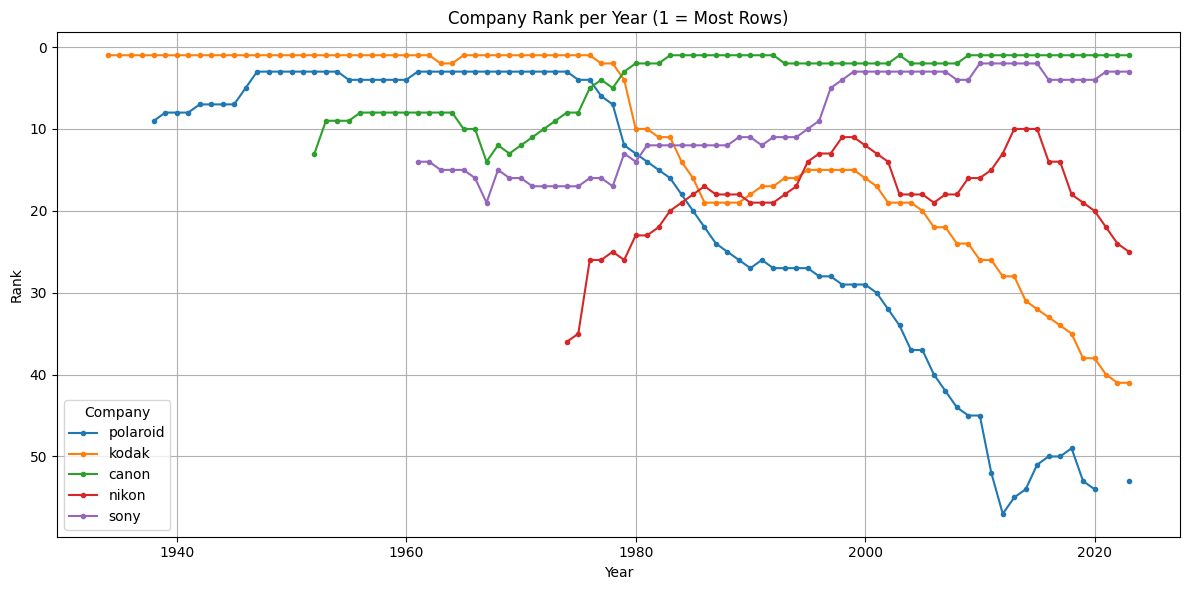

In [ ]:
## Step 3: Get company portfolio dataframe
# The year range to for the analysis
analysis_start = start_year
analysis_end = end_year

if_before_after = 'onpoint'
# if_before_after = 'after'

# Load the portfolio dataframe
df_company_year_portfolio = pd.read_csv(f'{embedding_path}df_company_year_portfolio_{if_before_after}.csv')

# Filter out all rows outside analysis year range, make sure the analysis range is within the selected patent year range
df_company_year_portfolio = df_company_year_portfolio[(df_company_year_portfolio["year"] >= analysis_start) & (df_company_year_portfolio["year"] <= analysis_end)]
df_company_year_portfolio.reset_index(drop=True, inplace=True)

import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Count the number of rows for each company per year
company_year_counts = df_company_year_portfolio.groupby(['year', 'company']).size().reset_index(name='count')

# Step 2: Rank companies by count within each year
company_year_counts['rank'] = company_year_counts.groupby('year')['count'].rank(ascending=False, method='first')

# Step 3: Filter for selected companies
# comp_interest = ['pentax', 'canon', 'nikon', 'minolta', 'sony']    # Shift 1960-1980
comp_interest = ['canon', 'nikon', 'sony', 'kodak', 'polaroid', 'pentax', ]    # Shift 1975-2010
# comp_interest = ['konica', 'minolta', 'canon', 'nikon', 'sony']    # Shift 2003-2006
# comp_interest = ['canon', 'nikon', 'sony', 'fuji', 'olympus', 'panasonic', 'samsung']  # Shift 2008–2020
filtered_counts = company_year_counts[company_year_counts['company'].isin(comp_interest)]

# Step 4: Pivot data for plotting
counts_pivot = filtered_counts.pivot(index='year', columns='company', values='count')
ranks_pivot = filtered_counts.pivot(index='year', columns='company', values='rank')

# Plotting the number of rows per year
plt.figure(figsize=(12, 6))
for company in comp_interest:
    if company in counts_pivot.columns:
        plt.plot(counts_pivot.index, counts_pivot[company], marker='.', label=company)
plt.title('Number of Rows per Company per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.grid(True)
plt.legend(title='Company')
plt.tight_layout()
plt.show()

# Plotting the ranks per year
plt.figure(figsize=(12, 6))
for company in comp_interest:
    if company in ranks_pivot.columns:
        plt.plot(ranks_pivot.index, ranks_pivot[company], marker='.', label=company)
plt.title('Company Rank per Year (1 = Most Rows)')
plt.xlabel('Year')
plt.ylabel('Rank')
plt.gca().invert_yaxis()  # Rank 1 at the top
plt.grid(True)
plt.legend(title='Company')
plt.tight_layout()
plt.show()

# Analysis on companies' proximity on critical patents

Parameter setting

In [ ]:
# Top_level = 10pct, camera industry, long and short list complied for shift driving meta-topics
full_list = list(range(0, 90))
item_to_exclude = [40, 41, 45, 48, 49, 63, 64, 54, 56, 57, 58, 12, 14, 15, 11, 33, 34, 44, 2, 52, 23, 37, 38, 19, 20, 7, 32]


long_list = [item for item in full_list if item not in item_to_exclude]


short_list = [3, 16, 21, 30, 53, 59, 60, 61, 66, 71, 73, 74, 75, 77, 79]

In [2]:
# ------------------------- Enable/Disable Metrics ------------------------- #
CALCULATE_NEAREST_NEIGHBOR = True
CALCULATE_KDE_KL          = False
CALCULATE_IFOREST         = False
CALCULATE_OCSVM           = False
CALCULATE_GAUSSIAN_KL     = False
CALCULATE_MAHALANOBIS     = True
CALCULATE_COSINE          = True

# ------------------------- Mahalanobis Regularization --------------------- #
REGULARIZE_MAHALANOBIS = True   # Set True to apply diagonal regularization
REGULARIZATION_EPSILON = 1e-5   # Small value added to diagonal

# ------------------------- Data Preparation ------------------------- #

if_before_after = 'onpoint'
# if_before_after = 'after'
# top_level = 'top1'    # top 1 each year
top_level = '10pct'    # top 10% each year

# # Load top important patents if "important"
# critical_patent_set = "important"
# top_percent = 10
# clusters = (None, "")    # Using all clusters
# shift_era = ""

# Load shift driving patents if "shift"
critical_patent_set = "shift"
year_window = 20


n_cluster = 75
shift_start = 1970
shift_end = 2010
shift_era = f"_{shift_start}_{shift_end}"
list_length = ''
clusters = (None, "")


# n_cluster = 91
# shift_start = 1975
# shift_end = 2010
# shift_era = f"_{shift_start}_{shift_end}"
# list_length = '_short_list'
# clusters = (short_list, '_core')
# list_length = '_long_list'
# clusters = (long_list, '_extended')


# shift_start = 1975
# shift_end = 1985
# shift_era = f"_{shift_start}_{shift_end}"
# clusters = (None, "")    # Using all clusters
# clusters = ([1, 3], "_semicoductor")    # Semiconductor Processes
# clusters = ([8, 23, 26], "_sensor")    # Imaging Sensors
# clusters = ([2, 5, 11, 22], "_imaging")    # Imaging Devices / Processing
# clusters = ([7], "_focus")    # Autofocus

# shift_start = 1995
# shift_end = 2010
# shift_era = f"_{shift_start}_{shift_end}"
# clusters = (None, "")    # Using all clusters
# clusters = ([1, 9], "_algorithm")    # Algorithm (Stabilization, Compression)
# clusters = ([2, 31, 37], "_mobile")    # Mobile Phone, Portability, Module Manufacturing
# clusters = ([10, 22], "_display")    # Display / LCD
# clusters = ([32], "_cmos")    # CMOS
# clusters = ([21], "_furtherdigital")    # Further Digitalization

# Main Steps for computing the proximity
Preparation for files

In [3]:
import pickle

## Step 1: Get the embedding dataframe, matching ids
# Get data of all patents
if dataset not in ["sampled", "test"]:
    df_id_year = pd.read_csv(f"{folder_path}df_id_year_document.csv")
else:
    df_id_year = pd.read_csv(f"{folder_path}df_id_year_document_{constant_patent_num}_{i_sampling}.csv")

print(f"Loaded {len(df_id_year)} records")

# Filter out years outside the overall range
df_id_year = df_id_year[
    (df_id_year["year"] >= start_year) &
    (df_id_year["year"] <= end_year)
]
df_id_year.reset_index(drop=True, inplace=True)
df_id_year = df_id_year.drop(columns=['document'], errors='ignore')
print(f"Filtered {len(df_id_year)} records for year range {start_year}-{end_year}")

# Get the number of patents during the shift
df_id_year_shift = df_id_year[
    (df_id_year["year"] >= shift_start) &
    (df_id_year["year"] <= shift_end)
]

print(f"{len(df_id_year_shift)} records for the shift yeaer {shift_start}-{shift_end}")

with open(f"{embedding_path}embeddings.pkl", "rb") as f:
    embeddings = pickle.load(f)
print('Embeddings loaded')

df_id_embeddings = pd.DataFrame(embeddings)
df_id_embeddings.insert(0, 'id', df_id_year['id'])

embedding_columns = df_id_embeddings.columns.tolist()[1:]
df_id_embeddings['embedding_vector'] = df_id_embeddings[embedding_columns].values.tolist()
df_id_embeddings = df_id_embeddings[['id', 'embedding_vector']]

print(f"Embedding vectors loaded with {len(df_id_embeddings)} records")

## Step 2: Get the critical patents
# If use the top important patents, filter out the id that do not show up in the top important patents
if critical_patent_set == 'important':
    df_top_important = pd.read_csv(f'{embedding_path}top_{top_percent}_percent_importance_by_year.csv')
    print(f"Loaded {len(df_top_important)} most important patents")
    df_id_year = df_id_year[df_id_year['id'].isin(df_top_important['id'])]

# If use the shift driving patents, filter out the id that do not show up in the shift driving patents
if critical_patent_set == 'shift':
    # df_shift_driving = pd.read_csv(f'{dynamic_topic_path}patent_shift_driving_cluster_id_year_{top_level}_{shift_start}_{shift_end}_{n_cluster}{list_length}.csv')
    df_shift_driving = pd.read_csv(f'{dynamic_topic_path}patent_refined_shift_driving_cluster_id_year_{top_level}_{shift_start}_{shift_end}_{n_cluster}{list_length}.csv')
    if clusters[1] != "":
        df_shift_driving = df_shift_driving[df_shift_driving['cluster_id'].isin(clusters[0])]
    df_shift_driving = df_shift_driving.drop_duplicates(subset=['id'])
    print(f"Loaded {len(df_shift_driving)} most shift driving patents")
    df_id_year = df_id_year[df_id_year['id'].isin(df_shift_driving['id'])]

print(f"Proportion of shift driving patents {len(df_shift_driving)/len(df_id_year_shift)}")

# Merge the selected df_id_year with the embedding dataframe
df_id_year = df_id_year.merge(df_id_embeddings, on='id', how='left')
print(f"Merged embeddings into df_id_year, total records: {len(df_id_year)}")

# Get the first and final year of the selected critical patents
first_year = df_id_year['year'].min()
final_year = df_id_year['year'].max()

print("First year:", first_year)
print("Final year:", final_year)

Loaded 1457933 records
Filtered 1457076 records for year range 1930-2023
1025899 records for the shift yeaer 1970-2010
Embeddings loaded
Embedding vectors loaded with 1457076 records
Loaded 396981 most shift driving patents
Proportion of shift driving patents 0.38695914510102847
Merged embeddings into df_id_year, total records: 396981
First year: 1969.0
Final year: 2011.0


patent_refined_shift_driving_clusters_id_year_10pct_1970_2010_75
patent_refined_shift_driving_cluster_id_year_10pct_1970_2010_75.csv

Get company portfolio dataframe

In [4]:
## Step 3: Get company portfolio dataframe
# The year range to for the analysis
analysis_start = 1970
analysis_end = 2010

# Load the portfolio dataframe
df_company_year_portfolio = pd.read_csv(f'{embedding_path}df_company_year_portfolio_{if_before_after}.csv')

# Filter out all rows outside analysis year range, make sure the analysis range is within the selected patent year range
df_company_year_portfolio = df_company_year_portfolio[(df_company_year_portfolio["year"] >= analysis_start) & (df_company_year_portfolio["year"] <= analysis_end)]
df_company_year_portfolio.reset_index(drop=True, inplace=True)

df_company_year_portfolio = df_company_year_portfolio.merge(df_id_embeddings, on='id', how='left')
print(f"Loaded and merged company portfolios, total records: {len(df_company_year_portfolio)}")

Loaded and merged company portfolios, total records: 4824621


## Find companies' proportion in critical patents

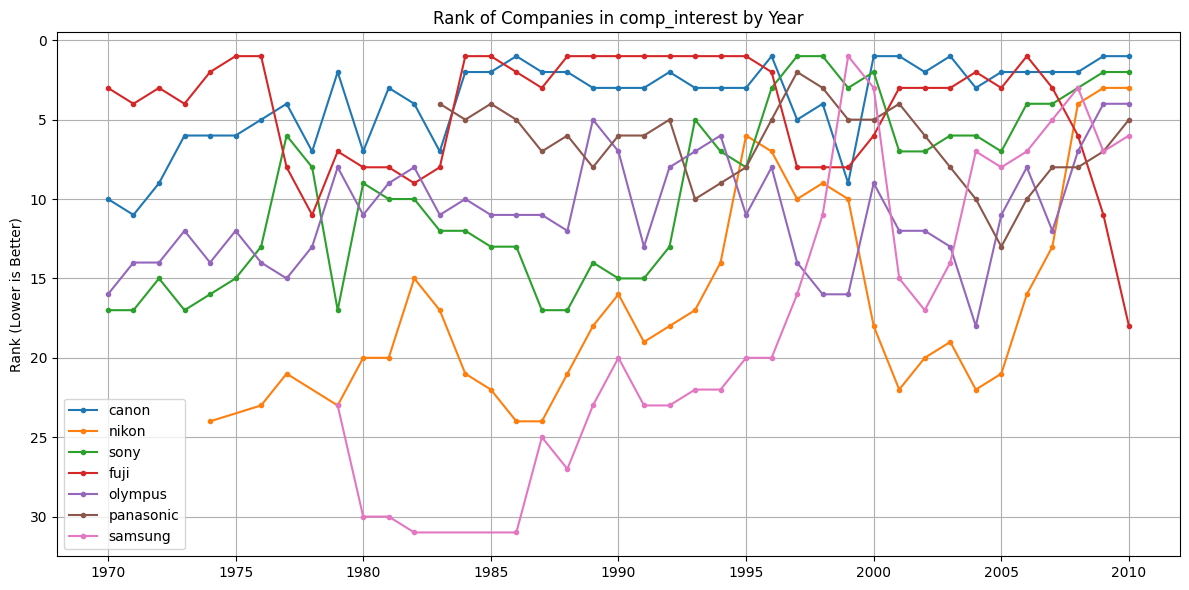

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Import df_company_id_year
df_company_id_year = pd.read_csv(f"{folder_path}df_company_id_year.csv")
df_company_id_year = df_company_id_year[(df_company_id_year["year"] >= analysis_start) & (df_company_id_year["year"] <= analysis_end)]


# Define comp_interest for different tech shift
# comp_interest = ['pentax', 'canon', 'nikon', 'minolta', 'sony']    # Shift 1960-1980
# comp_interest = ['canon', 'nikon', 'sony', 'kodak', 'polaroid', 'pentax', ]    # Shift 1975-2010 (shift1)
# comp_interest = ['konica', 'minolta', 'canon', 'nikon', 'sony']    # Shift 2003-2006
comp_interest = ['canon', 'nikon', 'sony', 'fuji', 'olympus', 'panasonic', 'samsung']  # Shift 2008–2020 (shift2)


# Filter df_company_id_year to keep only IDs in df_id_year
df_filtered = df_company_id_year[df_company_id_year['id'].isin(df_id_year['id'])]

# Calculate proportions and ranks
total_ids_per_year = df_filtered.groupby('year').size().reset_index(name='total_ids')
company_ids_per_year = df_filtered.groupby(['year', 'company']).size().reset_index(name='company_ids')
merged = company_ids_per_year.merge(total_ids_per_year, on='year')
merged['proportion'] = merged['company_ids'] / merged['total_ids']
merged['rank'] = merged.groupby('year')['proportion'].rank(method='dense', ascending=False).astype(int)
df_proportions = merged[['company', 'year', 'proportion', 'rank']]

# Find companies ranked 1st at least n times
n = 3  # Minimum number of times ranked 1st
top_1 = df_proportions[df_proportions['rank'] == 1][['company', 'year']].groupby('company').size().reset_index(name='top_1_count')
comp_top_1 = top_1[top_1['top_1_count'] >= n]['company'].tolist()

# Plot ranks
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))
fig, ax1 = plt.subplots(1, 1, figsize=(12, 6))


# Plot rank for comp_interest
for company in comp_interest:
    company_data = df_proportions[df_proportions['company'] == company]
    if not company_data.empty:
        ax1.plot(company_data['year'].tolist(), company_data['rank'].tolist(), marker='.', label=company)
ax1.set_title('Rank of Companies in comp_interest by Year')
ax1.set_ylabel('Rank (Lower is Better)')
ax1.invert_yaxis()
ax1.legend()
ax1.grid(True)

# # Plot proportion for comp_interest
# for company in comp_interest:
#     company_data = df_proportions[df_proportions['company'] == company]
#     if not company_data.empty:
#         ax2.plot(company_data['year'].tolist(), company_data['proportion'].tolist(), marker='.', label=company)
# ax2.set_title('Proportion of Companies in comp_interest by Year')
# ax2.set_ylabel('Proportion')
# ax2.legend()
# ax2.grid(True)

# # Plot comp_top_1
# for company in comp_top_1:
#     company_data = df_proportions[df_proportions['company'] == company]
#     if not company_data.empty:
#         ax2.plot(company_data['year'].tolist(), company_data['rank'].tolist(), marker='.', label=company)
# ax2.set_title('Rank of Top-1 Companies by Year')
# ax2.set_xlabel('Year')
# ax2.set_ylabel('Rank (Lower is Better)')
# ax2.invert_yaxis()
# ax2.legend()
# ax2.grid(True)

# plt.xlim(1970, 2000)
# plt.xlim(1995,2010)
plt.tight_layout()
# plt.savefig(f'{comprehensive_path}company_ranks_dominance_plot{critical_patent_set}{list_length}{shift_era}_shift1.png')
plt.savefig(f'{comprehensive_path}company_ranks_dominance_plot{critical_patent_set}{list_length}{shift_era}_shift2.png')
plt.show()

# Results are stored in df_proportions and comp_top_1

Main Calculation

In [6]:
!pip install hnswlib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for hnswlib: filename=hnswlib-0.8.0-cp311-cp311-linux_x86_64.whl size=2382529 sha256=99c47dfe53f0d59638d1b9dff94e4aaf36894cda9d8f6a5b620a78e324c00adf
  Stored in directory: /root/.cache/pip/wheels/ea/4e/27/39aebca9958719776e36fada290845a7ef10f053ad70e22ceb
Successfully built hnswlib


In [5]:
import numpy as np
import time
from scipy.spatial.distance import cosine
from numpy.linalg import inv, LinAlgError
import pickle

# For anomaly detection
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

# For KDE-based KL
from sklearn.neighbors import KernelDensity

# Import HNSWlib for approximate nearest neighbors
import hnswlib



# # ------------------------- Remove Specific Zero-Variance Dimensions ------------------------- #
# print("Step 4: Removing specific zero-variance dimensions")

# dims_to_remove = [127, 223, 319]

# def remove_dims(vec, dims):
#     if isinstance(vec, np.ndarray):
#         vec = vec.tolist()
#     return [v for i, v in enumerate(vec) if i not in dims]

# df_id_year['embedding_vector'] = df_id_year['embedding_vector'].apply(
#     lambda x: remove_dims(x, dims_to_remove) if x is not None else x
# )


# df_company_year_portfolio['embedding_vector'] = df_company_year_portfolio['embedding_vector'].apply(
#     lambda x: remove_dims(x, dims_to_remove) if x is not None else x
# )

# print(f"Removed dimensions {dims_to_remove} from all embedding vectors")

# ------------------------- Helper Functions ------------------------- #
def kl_divergence_gaussian(mean_p, cov_p, mean_q, cov_q):
    """Compute KL divergence between two multivariate Gaussians: KL(P || Q)."""
    if mean_p is None or cov_p is None or mean_q is None or cov_q is None:
        return np.nan
    dim = mean_p.shape[0]
    try:
        cov_q_inv = inv(cov_q)
    except LinAlgError:
        return np.nan
    trace_term = np.trace(cov_q_inv @ cov_p)
    mean_diff = mean_q - mean_p
    quad_term = mean_diff.T @ cov_q_inv @ mean_diff
    log_det_p = np.linalg.slogdet(cov_p)[1]  # log(det(cov_p))
    log_det_q = np.linalg.slogdet(cov_q)[1]  # log(det(cov_q))
    log_det_ratio = log_det_q - log_det_p
    return 0.5 * (trace_term + quad_term - dim + log_det_ratio)

def kl_divergence_kde(p_samples, q_samples, bandwidth=0.5):
    """Compute KL divergence KL(P||Q) using Kernel Density Estimation."""
    if len(p_samples) < 2 or len(q_samples) < 2:
        return np.nan
    kde_p = KernelDensity(bandwidth=bandwidth).fit(p_samples)
    kde_q = KernelDensity(bandwidth=bandwidth).fit(q_samples)
    log_p = kde_p.score_samples(p_samples)  # log density of P at points in P
    log_q = kde_q.score_samples(p_samples)  # log density of Q at points in P
    return np.mean(log_p - log_q)

# ------------------------- Distance + Anomaly Calculations ------------------------- #
print("Step 5: Starting Distance Calculations")

df_id_year['embedding_vector'] = df_id_year['embedding_vector'].apply(lambda x: np.array(x))
df_company_year_portfolio['embedding_vector'] = df_company_year_portfolio['embedding_vector'].apply(lambda x: np.array(x))

all_years = sorted(df_company_year_portfolio['year'].unique())
print(f"Calculating measures for {len(all_years)} years, but only the first year to test time-cost")

cosine_results      = []
mahalanobis_results = []
nn_results          = []
iforest_results     = []
ocsvm_results       = []
kl_results          = []
kde_kl_results      = []

for yr in all_years:
    print(f"\nProcessing Year: {yr}")

    df_docs_yr = df_id_year[df_id_year['year'] == yr]
    if len(df_docs_yr) == 0:
        print(f"  No documents for year {yr}, skipping.")
        continue

    doc_vectors_yr = np.stack(df_docs_yr['embedding_vector'].values)
    doc_center_of_mass = doc_vectors_yr.mean(axis=0)

    # For Gaussian KL
    if len(doc_vectors_yr) > 1:
        doc_cov = np.cov(doc_vectors_yr, rowvar=False)
    else:
        doc_cov = None

    df_companies_yr = df_company_year_portfolio[df_company_year_portfolio['year'] == yr]
    if len(df_companies_yr) == 0:
        print(f"  No companies for year {yr}, skipping.")
        continue

    companies_yr = df_companies_yr['company'].unique()
    print(f"  Found {len(companies_yr)} companies for year {yr}")

    for comp in companies_yr:
        df_comp_yr = df_companies_yr[df_companies_yr['company'] == comp]
        if len(df_comp_yr) == 0:
            continue

        comp_vectors = np.stack(df_comp_yr['embedding_vector'].values)
        comp_center_of_mass = comp_vectors.mean(axis=0)

        # (1) Cosine
        if CALCULATE_COSINE:
            start_t = time.time()
            cos_dist = cosine(doc_center_of_mass, comp_center_of_mass)
            cos_time = time.time() - start_t
            print(f"    {comp} - Cosine Distance = {cos_dist:.6f}, time = {cos_time:.4f}s")

            cosine_results.append({
                'year': yr,
                'company': comp,
                'ave_cosine_distance': cos_dist,
                'time_cosine': cos_time
            })

        # (2) Mahalanobis
        if CALCULATE_MAHALANOBIS:
            start_t = time.time()
            if len(comp_vectors) <= 1:
                avg_md = np.nan
                print(f"    {comp} - Not enough vectors for Mahalanobis distance")
            else:
                cov_comp = np.cov(comp_vectors, rowvar=False)

                # ----- New: Regularize or Shrink Covariance if chosen ----- #
                if REGULARIZE_MAHALANOBIS:
                    # Diagonal Regularization
                    eps_mat = np.eye(cov_comp.shape[0]) * REGULARIZATION_EPSILON
                    cov_comp = cov_comp + eps_mat

                try:
                    cov_inv = inv(cov_comp)
                    dist_list = []
                    for x in doc_vectors_yr:
                        diff = x - comp_center_of_mass
                        md_sq = diff @ cov_inv @ diff.T
                        dist_list.append(np.sqrt(md_sq))
                    avg_md = np.mean(dist_list)
                    print(f"    {comp} - Mahalanobis Distance = {avg_md:.6f}")
                except LinAlgError:
                    avg_md = np.nan
                    print(f"    {comp} - Singular covariance matrix, skipping Mahalanobis")
            mahala_time = time.time() - start_t
            print(f"      Mahalanobis time = {mahala_time:.4f}s")

            mahalanobis_results.append({
                'year': yr,
                'company': comp,
                'ave_mahalanobis_distance': avg_md,
                'time_mahalanobis': mahala_time
            })

        # (3) Nearest Neighbor using HNSWlib
        if CALCULATE_NEAREST_NEIGHBOR:
            start_t = time.time()
            if len(comp_vectors) < 1:
                avg_nn_dist = np.nan
                print(f"    {comp} - No vectors for nearest-neighbor distance")
            else:
                k = min(3, len(comp_vectors))

                # Build a small HNSW index for comp_vectors
                dim = comp_vectors.shape[1]
                p = hnswlib.Index(space='cosine', dim=dim)
                p.init_index(max_elements=len(comp_vectors), ef_construction=200, M=16)
                p.add_items(comp_vectors)

                # Tune ef for better accuracy/speed trade-off
                p.set_ef(50)

                nn_distances_for_all_docs = []
                for doc in doc_vectors_yr:
                    # Query top-k neighbors
                    labels, distances = p.knn_query(doc, k=k)
                    # distances is a 2D array: distances[0] are the distances for this single query
                    nn_mean = distances[0].mean()
                    nn_distances_for_all_docs.append(nn_mean)

                avg_nn_dist = np.mean(nn_distances_for_all_docs)
                print(f"    {comp} - Approx. Nearest Neighbor Distance = {avg_nn_dist:.6f}")

            nn_time = time.time() - start_t
            print(f"      Nearest Neighbor time = {nn_time:.4f}s")

            nn_results.append({
                'year': yr,
                'company': comp,
                'ave_nearest_neighbor_distance': avg_nn_dist,
                'time_nearest_neighbor': nn_time
            })

        # (4) Isolation Forest
        if CALCULATE_IFOREST:
            start_t = time.time()
            if len(comp_vectors) < 2:
                avg_iforest = np.nan
                print(f"    {comp} - Not enough vectors for Isolation Forest")
            else:
                iso_forest = IsolationForest(
                    n_estimators=100,
                    contamination='auto',
                    random_state=42
                )
                iso_forest.fit(comp_vectors)
                iso_scores = iso_forest.decision_function(doc_vectors_yr)
                avg_iforest = np.mean(iso_scores)
                print(f"    {comp} - IF Score = {avg_iforest:.6f}")
            iforest_time = time.time() - start_t
            print(f"      Isolation Forest time = {iforest_time:.4f}s")

            iforest_results.append({
                'year': yr,
                'company': comp,
                'avg_iforest_score': avg_iforest,
                'time_iforest': iforest_time
            })

        # (5) One-Class SVM
        if CALCULATE_OCSVM:
            start_t = time.time()
            if len(comp_vectors) < 2:
                avg_ocsvm = np.nan
                print(f"    {comp} - Not enough vectors for One-Class SVM")
            else:
                oc_svm = OneClassSVM(nu=0.05, kernel='rbf', gamma='scale')
                oc_svm.fit(comp_vectors)
                oc_scores = oc_svm.decision_function(doc_vectors_yr)
                avg_ocsvm = np.mean(oc_scores)
                print(f"    {comp} - OC-SVM Score = {avg_ocsvm:.6f}")
            ocsvm_time = time.time() - start_t
            print(f"      One-Class SVM time = {ocsvm_time:.4f}s")

            ocsvm_results.append({
                'year': yr,
                'company': comp,
                'avg_ocsvm_score': avg_ocsvm,
                'time_ocsvm': ocsvm_time
            })

        # (6) Gaussian KL-Divergence
        if CALCULATE_GAUSSIAN_KL:
            start_t = time.time()
            if doc_cov is None or len(comp_vectors) < 2:
                kl_val = np.nan
                print(f"    {comp} - Not enough vectors for Gaussian KL-Divergence")
            else:
                comp_cov = np.cov(comp_vectors, rowvar=False)
                kl_val = kl_divergence_gaussian(doc_center_of_mass, doc_cov, comp_center_of_mass, comp_cov)
                print(f"    {comp} - KL-Divergence (Gauss) = {kl_val:.6f}")
            kl_time = time.time() - start_t
            print(f"      Gaussian KL time = {kl_time:.4f}s")

            kl_results.append({
                'year': yr,
                'company': comp,
                'gaussian_kl_divergence': kl_val,
                'time_kl': kl_time
            })

        # (7) KDE KL-Divergence
        if CALCULATE_KDE_KL:
            start_t = time.time()
            kl_val_kde = kl_divergence_kde(doc_vectors_yr, comp_vectors, bandwidth=0.5)
            print(f"    {comp} - KL-Divergence (KDE) = {kl_val_kde:.6f}")
            kl_kde_time = time.time() - start_t
            print(f"      KDE KL time = {kl_kde_time:.4f}s")

            kde_kl_results.append({
                'year': yr,
                'company': comp,
                'kde_kl_divergence': kl_val_kde,
                'time_kde_kl': kl_kde_time
            })

# ------------------------- Save Results to CSV ------------------------- #
print("\nStep 7: Saving Results to CSV")

if CALCULATE_COSINE:
    df_cosine_results = pd.DataFrame(cosine_results)
    cos_csv = f"{comprehensive_path}cosine_distance_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
    df_cosine_results.to_csv(cos_csv, index=False)
    print(f"Cosine distances saved to: {cos_csv}")

if CALCULATE_MAHALANOBIS:
    df_mahalanobis_results = pd.DataFrame(mahalanobis_results)
    maha_csv = f"{comprehensive_path}mahalanobis_distance_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
    df_mahalanobis_results.to_csv(maha_csv, index=False)
    print(f"Mahalanobis distances saved to: {maha_csv}")

if CALCULATE_NEAREST_NEIGHBOR:
    df_nn_results = pd.DataFrame(nn_results)
    nn_csv = f"{comprehensive_path}nearest_neighbor_distance_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
    df_nn_results.to_csv(nn_csv, index=False)
    print(f"Nearest neighbor distances saved to: {nn_csv}")

if CALCULATE_IFOREST:
    df_iforest_results = pd.DataFrame(iforest_results)
    iforest_csv = f"{comprehensive_path}iforest_distance_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
    df_iforest_results.to_csv(iforest_csv, index=False)
    print(f"Isolation Forest scores saved to: {iforest_csv}")

if CALCULATE_OCSVM:
    df_ocsvm_results = pd.DataFrame(ocsvm_results)
    ocsvm_csv = f"{comprehensive_path}ocsvm_distance_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
    df_ocsvm_results.to_csv(ocsvm_csv, index=False)
    print(f"One-Class SVM scores saved to: {ocsvm_csv}")

if CALCULATE_GAUSSIAN_KL:
    df_kl_results = pd.DataFrame(kl_results)
    kl_csv = f"{comprehensive_path}kl_distance_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
    df_kl_results.to_csv(kl_csv, index=False)
    print(f"Gaussian KL-Divergence saved to: {kl_csv}")

if CALCULATE_KDE_KL:
    df_kde_kl_results = pd.DataFrame(kde_kl_results)
    kde_kl_csv = f"{comprehensive_path}kde_kl_distance_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
    df_kde_kl_results.to_csv(kde_kl_csv, index=False)
    print(f"KDE KL-Divergence saved to: {kde_kl_csv}")

print("\n Script completed successfully.")

Streaming output truncated to the last 5000 lines.
    leica - Approx. Nearest Neighbor Distance = 0.559811
      Nearest Neighbor time = 0.2754s
    lenovo - Cosine Distance = 0.425372, time = 0.0000s
    lenovo - Mahalanobis Distance = 324.784010
      Mahalanobis time = 0.3911s
    lenovo - Approx. Nearest Neighbor Distance = 0.733642
      Nearest Neighbor time = 0.1316s
    lg - Cosine Distance = 0.206638, time = 0.0000s
    lg - Mahalanobis Distance = 273.070119
      Mahalanobis time = 0.3995s
    lg - Approx. Nearest Neighbor Distance = 0.596745
      Nearest Neighbor time = 0.1544s
    logitech - Cosine Distance = 0.398461, time = 0.0001s
    logitech - Mahalanobis Distance = 320.772649
      Mahalanobis time = 0.3887s
    logitech - Approx. Nearest Neighbor Distance = 0.728230
      Nearest Neighbor time = 0.1359s
    microsoft - Cosine Distance = 0.410003, time = 0.0000s
    microsoft - Mahalanobis Distance = 299.438674
      Mahalanobis time = 0.4107s
    microsoft - Approx

Plot company trends by proximity measures and their ranks

Companies that have rank 1 at least 1 times: ['agfa', 'canon', 'fuji', 'hitachi', 'kodak', 'mitsubishi', 'olympus', 'panasonic', 'ricoh', 'sharp', 'toshiba']


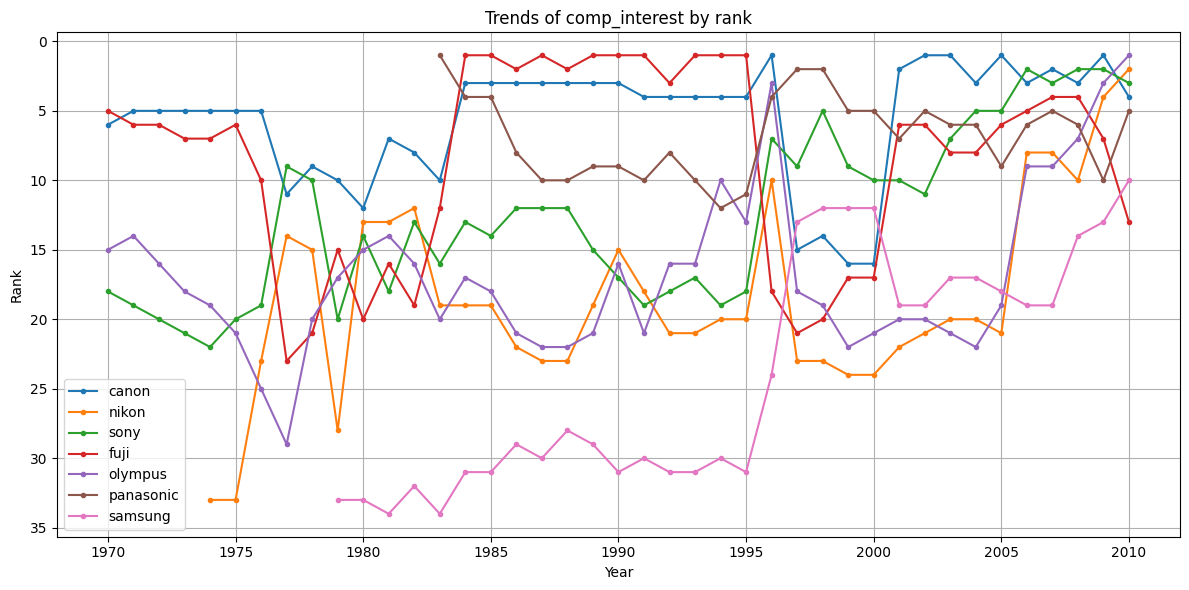

In [19]:
import matplotlib.pyplot as plt

# --- User-provided variables ---

if_before_after = 'onpoint'
# if_before_after = 'after'

measure = "cosine_distance"
measure_column = "ave_cosine_distance"
# measure = "mahalanobis_distance"
# measure_column = "ave_mahalanobis_distance"
# measure = "nearest_neighbor_distance"
# measure_column = "ave_nearest_neighbor_distance"

# Define comp_interest for different tech shift
# comp_interest = ['pentax', 'canon', 'nikon', 'minolta', 'sony']    # Shift 1960-1980
# comp_interest = ['canon', 'nikon', 'sony', 'kodak', 'polaroid', 'pentax', ]    # Shift 1975-2010
# comp_interest = ['konica', 'minolta', 'canon', 'nikon', 'sony']    # Shift 2003-2006
comp_interest = ['canon', 'nikon', 'sony', 'fuji', 'olympus', 'panasonic', 'samsung']  # Shift 2008–2020

## Clusters from shift 1970-2010
clusters = (None, "")

## Clusters from shift 1975-2010
# clusters = (short_list, "_core")
# clusters = (long_list, "_extended")

## Clusters from shift 1975-1985
# clusters = ([1, 3], "_semicoductor")    # Semiconductor Processes
# clusters = ([8, 23, 26], "_sensor")    # Imaging Sensors
# clusters = ([2, 5, 11, 22], "_imaging")    # Imaging Devices / Processing
# clusters = ([7], "_focus")    # Autofocus

## Clusters from shift 1995-2010
# clusters = ([1, 9], "_algorithm")    # Algorithm (Stabilization, Compression)
# clusters = ([2, 31, 37], "_mobile")    # Mobile Phone, Portability, Module Manufacturing
# clusters = ([10, 22], "_display")    # Display / LCD
# clusters = ([32], "_cmos")    # CMOS
# clusters = ([21], "_furtherdigital")    # Further Digitalization

top_record = 1    # number of times ranked at the top

# --- Load Data ---
df_year_company_measure = pd.read_csv(
    f"{comprehensive_path}{measure}_by_year_company_{if_before_after}_{critical_patent_set}{list_length}{shift_era}{clusters[1]}.csv"
)

# --- Step 1: Rank companies (by year) according to their measure_column ---
if measure == 'ocsvm_distance':
    df_year_company_measure['rank'] = df_year_company_measure.groupby('year')[measure_column].rank(method='dense', ascending=False)
else:
    df_year_company_measure['rank'] = df_year_company_measure.groupby('year')[measure_column].rank(method='dense', ascending=True)

# --- Step 2: Find companies that have rank 1 at least top_record times across all years ---
df_top_1 = df_year_company_measure[df_year_company_measure['rank'] == 1]
count_top_1 = df_top_1.groupby('company').size()
comp_top_1 = count_top_1[count_top_1 >= top_record].index.tolist()

print(f"Companies that have rank 1 at least {top_record} times:", comp_top_1)

# --- Prepare DataFrames for plotting ---
df_interest = df_year_company_measure[df_year_company_measure['company'].isin(comp_interest)]
df_top1_filtered = df_year_company_measure[df_year_company_measure['company'].isin(comp_top_1)]

# --- Step 3: Generate subplots (1 column x 4 rows) ---
# fig, axes = plt.subplots(4, 1, figsize=(12, 32), sharex=False)
# fig, axes = plt.subplots(2, 1, figsize=(12, 12), sharex=False)
fig, ax = plt.subplots(1, 1, figsize=(12, 6), sharex=False)

# 2. Trends of comp_interest by rank
ax.set_title("Trends of comp_interest by rank")
for company in comp_interest:
    sub_df = df_interest[df_interest['company'] == company]
    ax.plot(sub_df['year'], sub_df['rank'], marker='.', label=company)
ax.invert_yaxis()
ax.set_xlabel("Year")
ax.set_ylabel("Rank")
ax.legend()
ax.grid(True)
# ax.set_xlim(1970, 2000)
# ax.set_xlim(1995, 2010)


# # 1. Trends of comp_interest by measure_column
# axes[0].set_title("Trends of comp_interest by measure_column")
# for company in comp_interest:
#     sub_df = df_interest[df_interest['company'] == company]
#     axes[0].plot(sub_df['year'], sub_df[measure_column], marker='.', label=company)
# axes[0].set_xlabel("Year")
# axes[0].set_ylabel(measure_column)
# axes[0].legend()
# axes[0].grid(True)

# # 2. Trends of comp_interest by rank
# axes[1].set_title("Trends of comp_interest by rank")
# for company in comp_interest:
#     sub_df = df_interest[df_interest['company'] == company]
#     axes[1].plot(sub_df['year'], sub_df['rank'], marker='.', label=company)
# axes[1].invert_yaxis()
# axes[1].set_xlabel("Year")
# axes[1].set_ylabel("Rank")
# axes[1].legend()
# axes[1].grid(True)

# # 3. Trends of comp_top_1 by measure_column
# axes[2].set_title("Trends of comp_top_1 by measure_column")
# for company in comp_top_1:
#     sub_df = df_top1_filtered[df_top1_filtered['company'] == company]
#     axes[2].plot(sub_df['year'], sub_df[measure_column], marker='.', markersize=2, label=company)
# axes[2].set_xlabel("Year")
# axes[2].set_ylabel(measure_column)
# axes[2].legend()
# axes[2].grid(True)

# # 4. Trends of comp_top_1 by rank
# axes[3].set_title("Trends of comp_top_1 by rank")
# for company in comp_top_1:
#     sub_df = df_top1_filtered[df_top1_filtered['company'] == company]
#     axes[3].plot(sub_df['year'], sub_df['rank'], marker='.', markersize=2, label=company)
# axes[3].invert_yaxis()
# axes[3].set_xlabel("Year")
# axes[3].set_ylabel("Rank")
# axes[3].legend()
# axes[3].grid(True)

plt.tight_layout()

# --- Step 4: Save the figure ---
# plt.savefig(f"{comprehensive_path}trends_{measure}_by_year_company_{if_before_after}_{critical_patent_set}{shift_era}{clusters[1]}_shift1.png", dpi=300)
plt.savefig(f"{comprehensive_path}trends_{measure}_by_year_company_{if_before_after}_{critical_patent_set}{shift_era}{clusters[1]}_shift2.png", dpi=300)
plt.show()

## Plot incumbents and entrants trends for competence enhancing/destroying measure

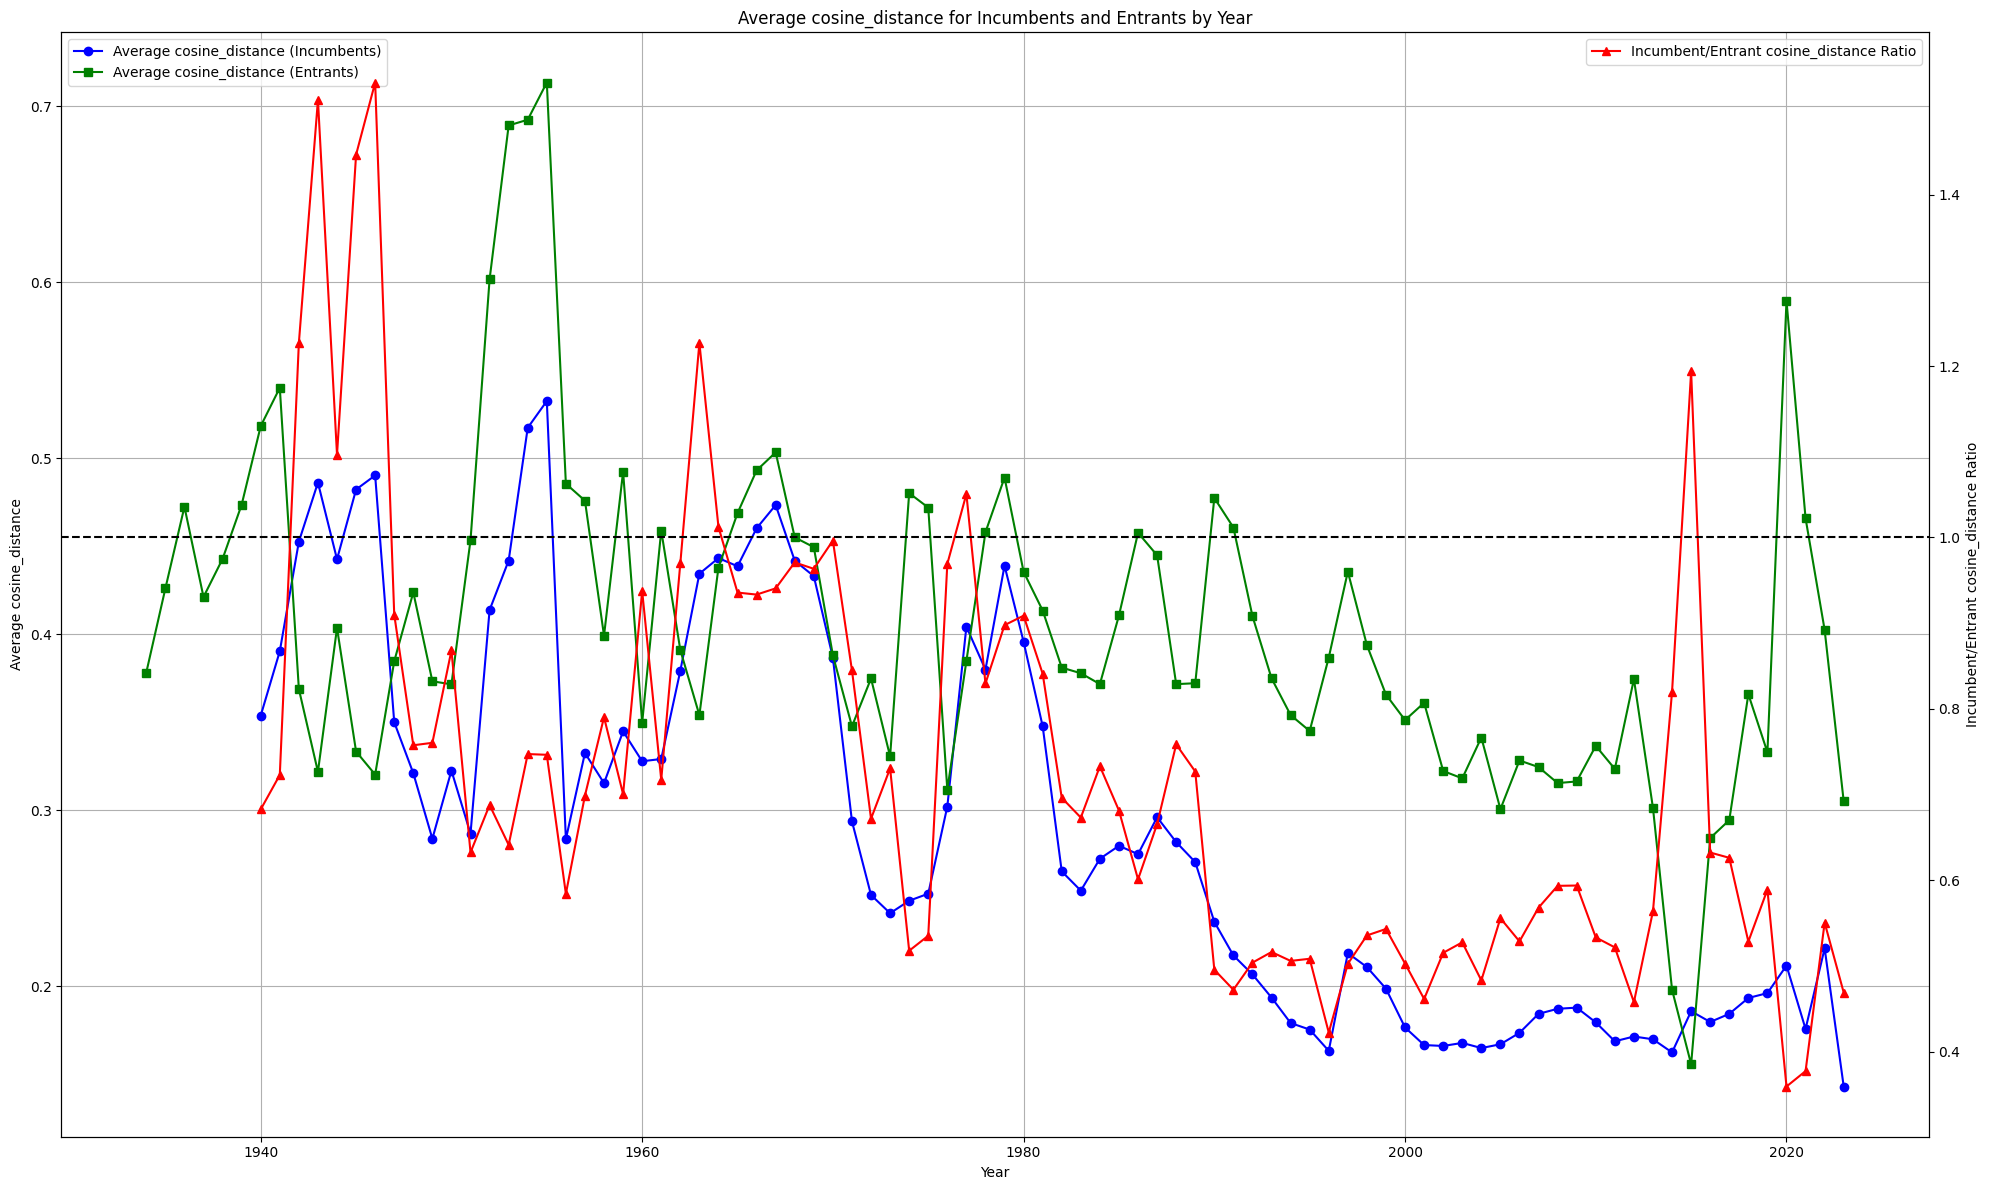

In [ ]:
## Re-enter the parameter
# Load top important patents if "important"
critical_patent_set = "important"
top_percent = 10
clusters = (None, "")    # Using all clusters
shift_era = ""

# # Load shift driving patents if "shift"
# critical_patent_set = "shift"
# year_window = 20

# shift_start = 1975
# shift_end = 1985
# shift_era = f"_{shift_start}_{shift_end}"
# clusters = (None, "")    # Using all clusters
# clusters = ([1, 3], "_semicoductor")    # Semiconductor Processes
# clusters = ([8, 23, 26], "_sensor")    # Imaging Sensors
# clusters = ([2, 5, 11, 22], "_imaging")    # Imaging Devices / Processing
# clusters = ([7], "_focus")    # Autofocus

# shift_start = 1995
# shift_end = 2010
# shift_era = f"_{shift_start}_{shift_end}"
# clusters = (None, "")    # Using all clusters
# clusters = ([1, 9], "_algorithm")    # Algorithm (Stabilization, Compression)
# clusters = ([2, 31, 37], "_mobile")    # Mobile Phone, Portability, Module Manufacturing
# clusters = ([10, 22], "_display")    # Display / LCD
# clusters = ([32], "_cmos")    # CMOS
# clusters = ([21], "_furtherdigital")    # Further Digitalization

# Type of proximity measure
measure = "cosine_distance"
measure_column = "ave_cosine_distance"
# measure = "mahalanobis_distance"
# measure_column = "ave_mahalanobis_distance"
# measure = "nearest_neighbor_distance"
# measure_column = "ave_nearest_neighbor_distance"
# measure = "ocsvm_distance"
# measure_column = "avg_ocsvm_score"

## Load data
# Company data
df_company_id_year = pd.read_csv(f"{folder_path}df_company_id_year.csv")
df_company_id_year = df_company_id_year[(df_company_id_year["year"] >= start_year) & (df_company_id_year["year"] <= end_year)]
df_company_id_year.reset_index(drop=True, inplace=True)

## Get incumbents and entrants for each year
# Get unique years
years = sorted(df_company_id_year['year'].unique())

# Initialize results
results = []

# Process each focal year
for year in years:
    # Define time windows
    active_start = year - 9     # Start of last 10 years (i-9 to i)
    active_end = year           # End of last 10 years (focal year)

    # Get companies with rows in each time window
    past_companies = set(df_company_id_year[df_company_id_year['year'] < active_start]['company'].unique())
    active_companies = set(df_company_id_year[(df_company_id_year['year'] >= active_start) &
                                             (df_company_id_year['year'] <= active_end)]['company'].unique())

    # Get inactive companies: no rows on or after active_start
    all_companies = set(df_company_id_year['company'].unique())
    inactive_companies = all_companies - set(df_company_id_year[df_company_id_year['year'] >= active_start]['company'].unique())

    # Identify incumbents: existed 10+ years ago and not inactive
    incumbents = past_companies - inactive_companies

    # Identify entrants: active in last 10 years but not existed 10+ years ago
    entrants = active_companies - past_companies


    # Add incumbents to results
    for company in incumbents:
        results.append({
            'year': year,
            'status': 'incumbent',
            'company': company
        })

    # Add entrants to results
    for company in entrants:
        results.append({
            'year': year,
            'status': 'entrant',
            'company': company
        })

# Convert results to DataFrame
df_incumbents_entrants = pd.DataFrame(results)

# Save results to CSV (optional, adjust path as needed)
df_incumbents_entrants.to_csv(f'{comprehensive_path}incumbents_entrants_by_year.csv', index=False)

## Proximity data
df_year_company_measure = pd.read_csv(
    f"{comprehensive_path}{measure}_by_year_company_{if_before_after}_{critical_patent_set}{shift_era}{clusters[1]}.csv"
)

## Main calculation
# Load proximity measure data
df_year_company_measure = pd.read_csv(
    f"{comprehensive_path}{measure}_by_year_company_{if_before_after}_{critical_patent_set}{shift_era}{clusters[1]}.csv"
)

# Merge df_year_company_measure with df_incumbents_entrants to get status
df_merged = df_year_company_measure.merge(
    df_incumbents_entrants,
    on=['year', 'company'],
    how='inner'
)

# Calculate average measure for incumbents and entrants by year
df_avg_measure = df_merged.groupby(['year', 'status'])[measure_column].mean().unstack().reset_index()

# Ensure columns for incumbents and entrants exist, fill NaN with 0 if no data
df_avg_measure['incumbent'] = df_avg_measure.get('incumbent', 0)
df_avg_measure['entrant'] = df_avg_measure.get('entrant', 0)

# Calculate ratio of incumbent to entrant average measure
df_avg_measure['ratio'] = df_avg_measure['incumbent'] / df_avg_measure['entrant'].replace(0, np.nan)  # Avoid division by zero

# Plotting
fig, ax1 = plt.subplots(figsize=(20, 12))

# Plot average measure for incumbents and entrants (left y-axis)
ax1.plot(df_avg_measure['year'], df_avg_measure['incumbent'], marker='o', label=f'Average {measure} (Incumbents)', color='blue')
ax1.plot(df_avg_measure['year'], df_avg_measure['entrant'], marker='s', label=f'Average {measure} (Entrants)', color='green')
ax1.set_xlabel('Year')
ax1.set_ylabel(f'Average {measure}')
ax1.legend(loc='upper left')
ax1.grid(True)

# Create second y-axis for ratio
ax2 = ax1.twinx()
ax2.plot(df_avg_measure['year'], df_avg_measure['ratio'], marker='^', label=f'Incumbent/Entrant {measure} Ratio', color='red')
ax2.axhline(1, color='black', ls='--')
ax2.set_ylabel(f'Incumbent/Entrant {measure} Ratio')
ax2.legend(loc='upper right')


# Set title and adjust layout
plt.title(f'Average {measure} for Incumbents and Entrants by Year')
fig.tight_layout()

# Save plot
plt.savefig(f'{comprehensive_path}{measure}_incumbents_entrants_plot_{if_before_after}_{critical_patent_set}{shift_era}{clusters[1]}.png')
plt.show()

# Companies' network centralization

Loaded and merged company portfolios, total records: 7199422
Year 1934 processed
Year 1935 processed
Year 1936 processed
Year 1937 processed
Year 1938 processed
Year 1939 processed
Year 1940 processed
Year 1941 processed
Year 1942 processed
Year 1943 processed
Year 1944 processed
Year 1945 processed
Year 1946 processed
Year 1947 processed
Year 1948 processed
Year 1949 processed
Year 1950 processed
Year 1951 processed
Year 1952 processed
Year 1953 processed
Year 1954 processed
Year 1955 processed
Year 1956 processed
Year 1957 processed
Year 1958 processed
Year 1959 processed
Year 1960 processed
Year 1961 processed
Year 1962 processed
Year 1963 processed
Year 1964 processed
Year 1965 processed
Year 1966 processed
Year 1967 processed
Year 1968 processed
Year 1969 processed
Year 1970 processed
Year 1971 processed
Year 1972 processed
Year 1973 processed
Year 1974 processed
Year 1975 processed
Year 1976 processed
Year 1977 processed
Year 1978 processed
Year 1979 processed
Year 1980 processed

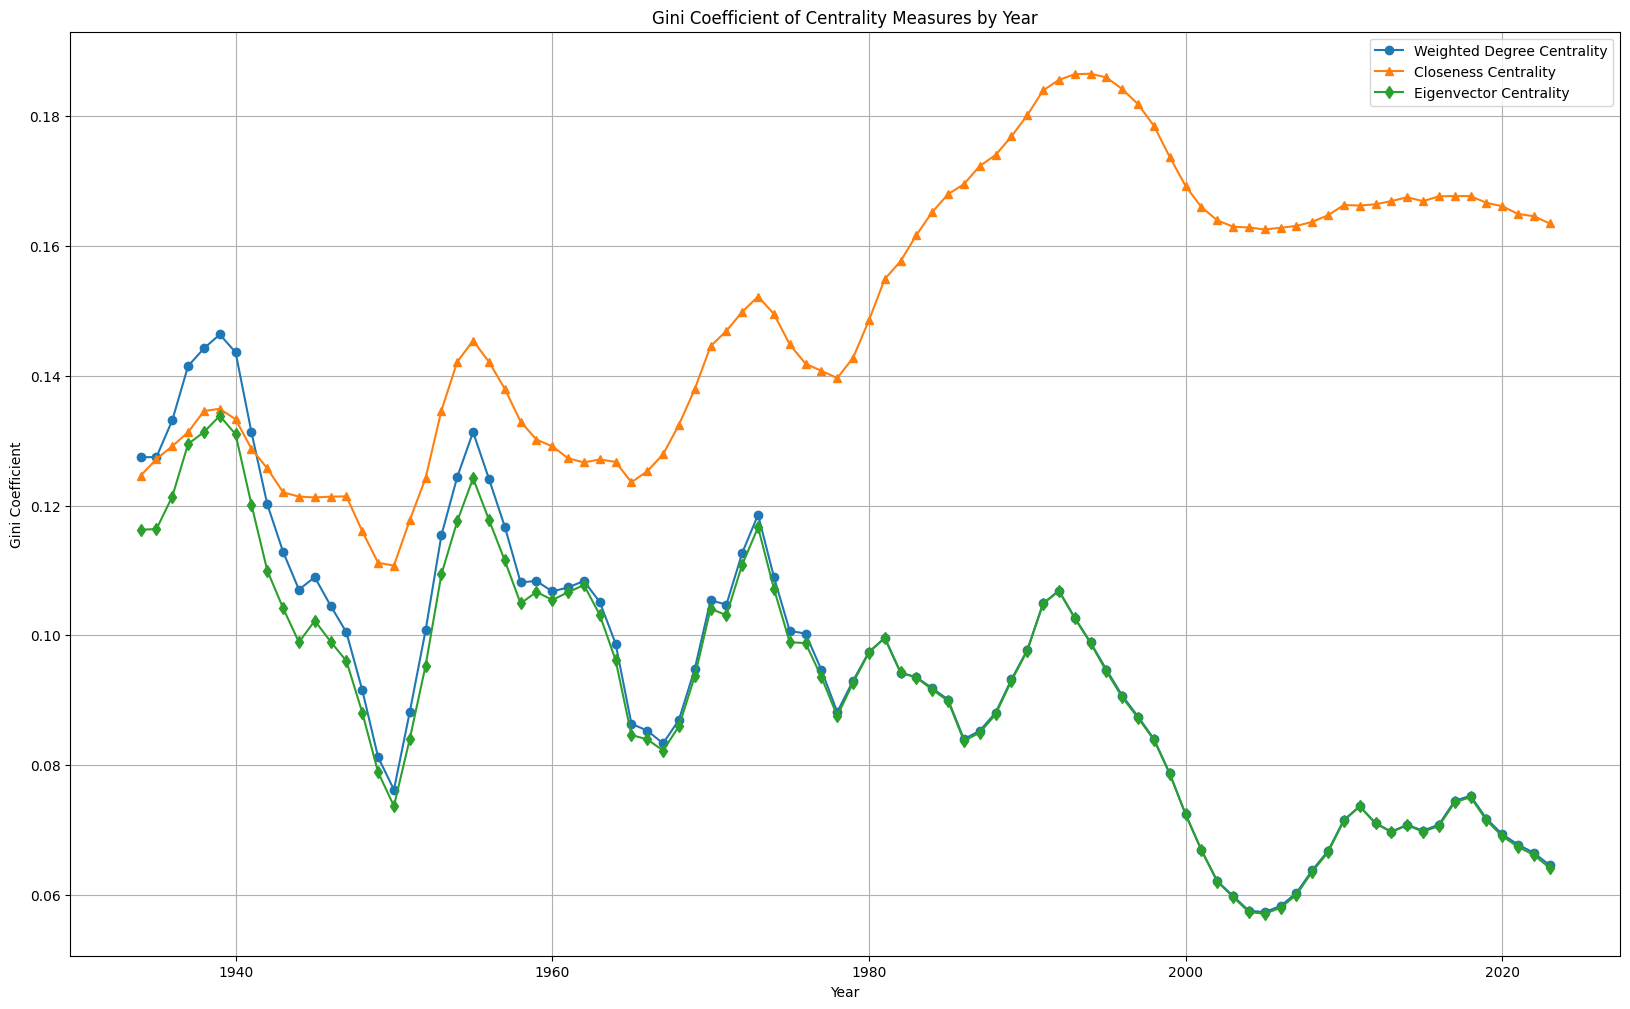

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt

import sys
sys.path.append('/content/drive/MyDrive/TechShiftProject')
from basic_func import *

# Load the portfolio dataframe
df_company_year_portfolio = pd.read_csv(f'{embedding_path}df_company_year_portfolio_{if_before_after}.csv')

# Filter out all rows outside analysis year range
df_company_year_portfolio = df_company_year_portfolio[(df_company_year_portfolio["year"] >= start_year) & (df_company_year_portfolio["year"] <= end_year)]
df_company_year_portfolio.reset_index(drop=True, inplace=True)

df_company_year_portfolio = df_company_year_portfolio.merge(df_id_embeddings, on='id', how='left')
print(f"Loaded and merged company portfolios, total records: {len(df_company_year_portfolio)}")

# Convert embedding_vector to numpy arrays if they are lists
df_company_year_portfolio['embedding_vector'] = df_company_year_portfolio['embedding_vector'].apply(
    lambda x: np.array(x) if isinstance(x, list) else x
)

# Step 1: Compute centroids per company per year
centroids = df_company_year_portfolio.groupby(['year', 'company'])['embedding_vector'].apply(
    lambda x: np.mean(np.stack(x), axis=0)
).reset_index()

# Step 2: Compute pairwise cosine similarities and distances, build graphs, and calculate centralities
years = centroids['year'].unique()
centrality_data = []
gini_data = []

for year in years:
    # Filter centroids for the year
    year_centroids = centroids[centroids['year'] == year]
    companies = year_centroids['company'].values
    vectors = year_centroids['embedding_vector'].values

    # Create graph
    G = nx.Graph()
    G.add_nodes_from(companies)

    # Compute pairwise cosine similarities (weights) and distances
    for i in range(len(companies)):
        for j in range(i + 1, len(companies)):
            sim = 1 - cosine(vectors[i], vectors[j])  # Cosine similarity
            dist = cosine(vectors[i], vectors[j])     # Cosine distance
            G.add_edge(companies[i], companies[j], weight=sim, distance=dist)

    # Calculate centrality measures
    # Weighted degree centrality: sum of edge weights normalized by (n-1)
    n = len(companies)
    weighted_degree = {node: sum(data['weight'] for _, _, data in G.edges(node, data=True)) / (n - 1)
                      for node in G.nodes()}
    closeness_centrality = nx.closeness_centrality(G, distance='distance')
    eigenvector_centrality = nx.eigenvector_centrality(G, weight='weight', max_iter=1000, tol=1e-6)

    # Store centrality measures
    for company in companies:
        centrality_data.append({
            'year': year,
            'company': company,
            'weighted_degree_centrality': weighted_degree.get(company, 0),
            'closeness_centrality': closeness_centrality.get(company, 0),
            'eigenvector_centrality': eigenvector_centrality.get(company, 0)
        })

    # Step 3: Compute Gini coefficient for each centrality measure
    def gini_coefficient(values):
        values = np.array(values, dtype=float)
        if len(values) == 0:
            return 0
        values = np.sort(values)
        n = len(values)
        cumulative_sum = np.cumsum(values)
        total_sum = cumulative_sum[-1]
        if total_sum == 0:
            return 0
        gini = (n + 1 - 2 * np.sum(cumulative_sum / total_sum)) / n
        return max(0, gini)  # Ensure non-negative

    gini_data.append({
        'year': year,
        'weighted_degree_gini': gini_coefficient([weighted_degree[c] for c in companies]),
        'closeness_gini': gini_coefficient([closeness_centrality[c] for c in companies]),
        'eigenvector_gini': gini_coefficient([eigenvector_centrality[c] for c in companies])
    })

    print(f"Year {year} processed")

# Convert results to DataFrames
df_centralities = pd.DataFrame(centrality_data)
df_gini = pd.DataFrame(gini_data)

# Calculate the moving average of gini coefficients
max_window_size = 5
ave_gini_weighted_degree = flexible_moving_average(df_gini['weighted_degree_gini'].tolist(), max_window_size)
ave_gini_closeness = flexible_moving_average(df_gini['closeness_gini'].tolist(), max_window_size)
ave_gini_eigenvector = flexible_moving_average(df_gini['eigenvector_gini'].tolist(), max_window_size)

df_centralities.to_csv(f"{comprehensive_path}centralities_by_year.csv", index=False)
df_gini.to_csv(f"{comprehensive_path}gini_coefficients_by_year.csv", index=False)

# Step 4: Plot Gini coefficients
plt.figure(figsize=(20, 12))
plt.plot(df_gini['year'], ave_gini_weighted_degree, marker='o', label='Weighted Degree Centrality')
plt.plot(df_gini['year'], ave_gini_closeness, marker='^', label='Closeness Centrality')
plt.plot(df_gini['year'], ave_gini_eigenvector, marker='d', label='Eigenvector Centrality')
plt.title('Gini Coefficient of Centrality Measures by Year')
plt.xlabel('Year')
plt.ylabel('Gini Coefficient')
plt.legend()
plt.grid(True)
plt.savefig(f'{comprehensive_path}gini_centrality_plot.png')
plt.show()

# Results are stored in df_centralities (company centralities) and df_gini (Gini coefficients)